In [1]:
import sys
sys.path.append('.')
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
import astropy.io.fits as fits
import math
import pandas as pd
import os
import subprocess
import re
from astropy.visualization import simple_norm

In [2]:
column_names = [
    "Source_id", "Isl_id", "RA", "E_RA", "DEC", "E_DEC", "Total_flux", "E_Total_flux",
    "Peak_flux", "E_Peak_flux", "RA_max", "E_RA_max", "DEC_max", "E_DEC_max", "Maj", 
    "E_Maj", "Min", "E_Min", "PA", "E_PA", "Maj_img_plane", "E_Maj_img_plane", 
    "Min_img_plane", "E_Min_img_plane", "PA_img_plane", "E_PA_img_plane", "DC_Maj", 
    "E_DC_Maj", "DC_Min", "E_DC_Min", "DC_PA", "E_DC_PA", "DC_Maj_img_plane", 
    "E_DC_Maj_img_plane", "DC_Min_img_plane", "E_DC_Min_img_plane", "DC_PA_img_plane", 
    "E_DC_PA_img_plane", "Isl_Total_flux", "E_Isl_Total_flux", "Isl_rms", "Isl_mean", 
    "Resid_Isl_rms", "Resid_Isl_mean", "S_Code"
]

In [3]:
# Define the file path
file_path = '../paper1/spw/25_pb/03:25:30.000000_+29.29.59.99999spwALL-2.5arcsec-nit5000--awproject.image.tt0.pbcor.pybdsf.srl'

# Lists to store the data
data = []

# Check if the file exists
if os.path.exists(file_path):
    with open(file_path, 'r') as file:
        for line in file:
            # Skip comment lines and empty lines
            if line.startswith('#') or not line.strip():
                continue

            # Use regex to split by multiple spaces (to handle inconsistent spacing)
            columns = re.split(r'\s+', line.strip())

            # Ensure we only process lines with the expected number of columns
            if len(columns) == len(column_names):
                data.append(columns)
            else:
                print(f"Skipping line due to unexpected number of columns: {line}")

    # Convert the processed data to a DataFrame
    df = pd.DataFrame(data, columns=column_names)

    # Save to CSV
    output_csv = '../paper2/25/25_cleaned.csv'
    df.to_csv(output_csv, index=False)
    print(f"Cleaned file saved as {output_csv}")
    
    # Extract RA and DEC columns into lists
    ra_list = df['RA'].tolist()
    dec_list = df['DEC'].tolist()

    # Output the RA and DEC lists
    print("RA List (first 5 entries):", ra_list[:5])
    print("DEC List (first 5 entries):", dec_list[:5])
else:
    print(f"File not found: {file_path}")


Cleaned file saved as ../paper2/25/25_cleaned.csv
RA List (first 5 entries): ['52.99012618881203', '52.99972840790387', '52.98103990283398', '52.96763862771937', '52.97285140242573']
DEC List (first 5 entries): ['29.39003997412658', '29.40331396056978', '29.55880295973608', '28.81899492215022', '29.36100977723261']


In [4]:
# Function to read data from a .pro file
def setup_columns(pro_file, noise_value, lines_to_skip=5):
    with open(pro_file, 'r') as file:
        lines = file.read().splitlines()[lines_to_skip:]  # Skip header lines
        lines = [ 
            [l.strip() for l in line.split()]  # Split each line by whitespace
            for line in lines
        ]
        lines = np.array(lines).transpose()  # Transpose to get columns
        
        # Extract frequency, flux, and flag columns from the file
        freq = np.double(lines[0])
        flux = np.double(lines[1])
        flag = np.double(lines[2])
        noise = np.copy(freq) * 0.0 + noise_value  # Initialize noise array
        
        return freq, flux, flag, noise

# Define paths to the pro files for Stokes I, Q, U
Stokes = ['I', 'Q', 'U']
dx = 4
dy = 4

# Define the directory for output files
output_dir = "../paper2/25/RMsyn/"
output_sources_list = "kept_sources_coordinates.txt"  # File to save the list of kept sources coordinates

# Ensure the directory exists; if not, create it
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# List to store (RA, DEC) coordinates of sources that were kept
kept_sources_coordinates = []

# Assuming the RA and DEC lists have been created from the previous part
for ip, (ra, dec) in enumerate(zip(ra_list, dec_list)):
    try:
        # Ensure RA and DEC are converted to float
        ra = float(ra)
        dec = float(dec)
    except ValueError:
        print(f"Skipping source {ip} due to non-numeric RA/DEC values: RA={ra}, DEC={dec}")
        continue

    # Create the source name based on RA and DEC, handling the sign correctly
    if dec >= 0:
        sourcename_RADEC = f"H{ra:+07.3f}+{dec:06.3f}"  # Avoid double '+' signs
    else:
        sourcename_RADEC = f"H{ra:+07.3f}{dec:06.3f}"

    # Generate the .pro filenames for each Stokes parameter (I, Q, U)
    I_pro_file = f"{sourcename_RADEC}_{dx}_{dy}_I.pro"
    Q_pro_file = f"{sourcename_RADEC}_{dx}_{dy}_Q.pro"
    U_pro_file = f"{sourcename_RADEC}_{dx}_{dy}_U.pro"

    # Paths to the files (update the path based on your file structure)
    I_pro_file_path = f"../paper2/25/sources/{I_pro_file}"
    Q_pro_file_path = f"../paper2/25/sources/{Q_pro_file}"
    U_pro_file_path = f"../paper2/25/sources/{U_pro_file}"
    
    # Ensure the .pro files exist before processing
    if not (os.path.exists(I_pro_file_path) and os.path.exists(Q_pro_file_path) and os.path.exists(U_pro_file_path)):
        print(f"One or more pro files missing for source {sourcename_RADEC}. Skipping...")
        continue
    
    # Set up columns for each Stokes parameter (assuming noise_value=9*1e-5)
    freq_I, flux_I, flag_I, noise_I = setup_columns(I_pro_file_path, 9*1e-5, lines_to_skip=5)
    freq_Q, flux_Q, flag_Q, noise_Q = setup_columns(Q_pro_file_path, 9*1e-5, lines_to_skip=5)
    freq_U, flux_U, flag_U, noise_U = setup_columns(U_pro_file_path, 9*1e-5, lines_to_skip=5)
    
    # Process the flags for NaN values
    for i in range(len(freq_I)):
        if np.isnan(flux_I[i]):
            flag_I[i] = 3
        if np.isnan(flux_Q[i]):
            flag_Q[i] = 3
        if np.isnan(flux_U[i]):
            flag_U[i] = 3

    # Write the cleaned data to a new file, one file per source
    output_file_path = f"{output_dir}{sourcename_RADEC}_combined.dat"
    with open(output_file_path, "w") as f:
        print(f"Writing cleaned data for {sourcename_RADEC}")
        for i in range(len(freq_I)):
            if (flag_I[i] < 1) and (flag_Q[i] < 1) and (flag_U[i] < 1):
                if (freq_I[i] == freq_Q[i]) and (freq_I[i] == freq_U[i]):
                    print(
                        "%15.8e  %15.8e  %15.8e  %15.8e  %15.8e  %15.8e  %15.8e" % 
                        (freq_I[i], flux_I[i], flux_Q[i], flux_U[i], noise_I[i], noise_Q[i], noise_U[i]),
                        file=f
                    )
        # If the file was created, add the (RA, DEC) tuple to kept_sources_coordinates list
        kept_sources_coordinates.append((ra, dec))

# Save the list of kept (RA, DEC) coordinates to a file
with open(output_sources_list, "w") as f:
    for ra, dec in kept_sources_coordinates:
        f.write(f"{ra} {dec}\n")

print("Processing complete.")
print(f"List of kept source coordinates saved to {output_sources_list}")


One or more pro files missing for source H+52.990+29.390. Skipping...
One or more pro files missing for source H+53.000+29.403. Skipping...
One or more pro files missing for source H+52.981+29.559. Skipping...
One or more pro files missing for source H+52.968+28.819. Skipping...
One or more pro files missing for source H+52.973+29.361. Skipping...
One or more pro files missing for source H+52.967+29.390. Skipping...
One or more pro files missing for source H+52.919+28.680. Skipping...
One or more pro files missing for source H+52.857+28.275. Skipping...
One or more pro files missing for source H+52.871+28.263. Skipping...
One or more pro files missing for source H+52.889+28.970. Skipping...
One or more pro files missing for source H+52.810+29.766. Skipping...
One or more pro files missing for source H+52.744+29.192. Skipping...
One or more pro files missing for source H+52.693+29.280. Skipping...
One or more pro files missing for source H+52.699+29.838. Skipping...
One or more pro file

Writing cleaned data for H+51.435+29.875
Writing cleaned data for H+51.427+29.167
One or more pro files missing for source H+51.429+28.146. Skipping...
Writing cleaned data for H+51.397+29.026
Writing cleaned data for H+51.402+29.224
Writing cleaned data for H+51.397+29.747
Writing cleaned data for H+51.388+29.811
Writing cleaned data for H+51.372+29.401
Writing cleaned data for H+51.375+29.879
Writing cleaned data for H+51.368+29.166
Writing cleaned data for H+51.375+29.183
Writing cleaned data for H+51.373+28.783
Writing cleaned data for H+51.365+30.290
Writing cleaned data for H+51.365+30.540
Writing cleaned data for H+51.358+29.992
One or more pro files missing for source H+51.359+28.237. Skipping...
Writing cleaned data for H+51.348+30.668
Writing cleaned data for H+51.349+29.459
Writing cleaned data for H+51.341+30.332
Writing cleaned data for H+51.341+28.655
Writing cleaned data for H+51.339+28.713
Writing cleaned data for H+51.339+29.141
Writing cleaned data for H+51.337+28.732

In [5]:
print(kept_sources_coordinates)

[(52.46085323676467, 29.13338364070054), (52.46468177754066, 29.82123001128862), (52.40842456836465, 29.84853280143574), (52.37252703218359, 29.20377013212232), (52.36701884735205, 30.18180211324925), (52.31715151042843, 28.87541988998652), (52.27148990116894, 29.73780725997456), (52.24945855493949, 28.68761434284782), (52.21725154855564, 29.51013001638329), (52.23035185570454, 29.52817278762965), (52.21296338892216, 29.01741957452435), (52.21524631236591, 29.35179162651121), (52.20373803116981, 29.82725480506105), (52.18885443225638, 28.97978359088518), (52.15035968345318, 29.36554134302438), (52.15053509779108, 28.77108614349686), (52.1211473002335, 28.98152862765125), (52.09449071887408, 29.001708298174), (52.11081717914249, 29.01823419684023), (52.11692299423639, 29.9777044131407), (52.11277430794964, 30.4380251971641), (52.1131259187794, 30.19122893257784), (52.09775046607891, 28.62654616525573), (52.11076135295047, 29.73365949581133), (52.11133913598552, 30.16310586976698), (52.0

Set OBSGEO-B to    34.078827 from OBSGEO-[XYZ].
Set OBSGEO-H to     2115.607 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


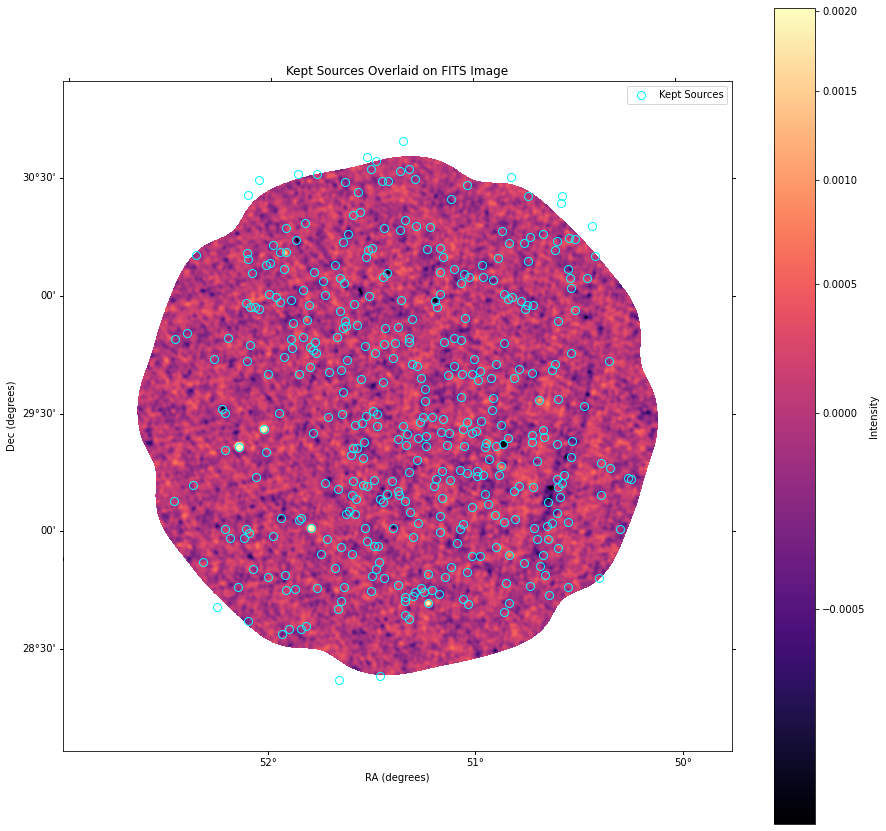

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import simple_norm

# Load the kept sources list
kept_sources_file = "kept_sources_coordinates.txt"
kept_sources = np.loadtxt(kept_sources_file)

# Load the FITS file and WCS information
fits_file = '../paper2/25/spw2-16~23-2.5arcsec-nit5000-2e-4-Q.image.smo.fits'
hdulist = fits.open(fits_file)
img_data = hdulist[0].data
wcs = WCS(hdulist[0].header)
hdulist.close()

# Adjust the image data to 2D if necessary
if img_data.ndim > 2:
    img_data = img_data[0, 0, :, :]  # Selecting the first Stokes and frequency slice

# Apply normalization with `simple_norm`
norm = simple_norm(img_data, 'sqrt', percent=99.9)

# Prepare RA and DEC with additional placeholder dimensions for frequency and Stokes
ra_list = kept_sources[:, 0]
dec_list = kept_sources[:, 1]
frequency = 1.47339395E9  # Placeholder frequency
stokes = 0  # Placeholder Stokes parameter
world_coords = np.column_stack((ra_list, dec_list, [frequency] * len(ra_list), [stokes] * len(dec_list)))

# Convert RA and DEC to pixel coordinates
pixel_coords = wcs.all_world2pix(world_coords, 0)

# Plotting
plt.figure(figsize=(15, 15))
ax = plt.subplot(projection=wcs, slices=('x', 'y', 0, 0))  # Specify 4D slices to project correctly
plt.imshow(img_data, origin='lower', cmap='magma', norm=norm)  # Change cmap to 'magma' for similar color tone
plt.colorbar(label='Intensity')

# Overlay the source positions with unfilled circles
ax.plot(pixel_coords[:, 0], pixel_coords[:, 1], 'o', markerfacecolor='none', color='cyan', markersize=8, label='Kept Sources')

# Set the coordinates format to degrees
ax.coords['ra'].set_format_unit('deg')
ax.coords['dec'].set_format_unit('deg')

plt.xlabel('RA (degrees)')
plt.ylabel('Dec (degrees)')
plt.legend()
plt.title("Kept Sources Overlaid on FITS Image")
plt.grid(True)

plt.show()


In [7]:
# Path where your RM synthesis script is located
rm_synthesis_script = "/Users/halehhajizadeh/Documents/RM-Tools-master/RMtools_1D/do_RMsynth_1D.py"

# Directory where your .dat files are located
dat_dir = "../paper2/25/RMsyn/"

# List all .dat files in the directory
dat_files = [f for f in os.listdir(dat_dir) if f.endswith('.dat')]

# Loop through each .dat file
for dat_file in dat_files:
    dat_file_path = os.path.join(dat_dir, dat_file)
    
    # Define the RM synthesis command
    command = [
        "python3", rm_synthesis_script,
        "-l", "-4000",  # Lower bound for Faraday depth
        "-d", "5",      # Faraday depth step size (note: separated '-d' and '5')
        "-w", "uniform", # Weighting scheme
        "-p",
        "-S",
        dat_file_path,  # Input .dat file (without -s flag)
    ]
    
    # Run the RM synthesis command for the current .dat file
    print(f"Running RM synthesis for: {dat_file_path}")
    subprocess.run(command)

print("RM synthesis completed for all .dat files.")


Running RM synthesis for: ../paper2/25/RMsyn/H+51.503+30.212_combined.dat
Figure(1200x800)
Figure(1200x800)
Running RM synthesis for: ../paper2/25/RMsyn/H+51.532+30.175_combined_RMSF.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+51.175+28.742_combined_FDFdirty.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+51.284+30.309_combined_RMsynth.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+51.465+28.878_combined_RMsynth.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+50.572+30.403_combined_FDFdirty.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+50.860+29.047_combined_weight.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+50.852+29.810_combined_RMsynth.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+52.465+29.821_combined.dat
Figure(1200x800)
Figure(1200x800)
Running RM synthesis for: ../paper2/25/RMsyn/H+52.090+30.107_combined.dat
Figure(1200x800)
Figure(1200x800)
Running RM synthesis for: ../paper2/25/RMsyn/H+51.874+30.247_combined_RMsynth.dat
Running RM synthesis f

Running RM synthesis for: ../paper2/25/RMsyn/H+52.015+29.346_combined_weight.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+52.094+29.002_combined_FDFdirty.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+51.659+29.944_combined_RMsynth.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+52.098+29.798_combined.dat
Figure(1200x800)
Figure(1200x800)
Running RM synthesis for: ../paper2/25/RMsyn/H+51.804+29.706_combined.dat
Figure(1200x800)
Figure(1200x800)
Running RM synthesis for: ../paper2/25/RMsyn/H+50.503+30.249_combined_RMsynth.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+51.151+29.487_combined_RMsynth.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+50.600+29.380_combined_RMSF.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+50.527+29.767_combined_weight.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+50.712+29.023_combined.dat
Figure(1200x800)
Figure(1200x800)
Running RM synthesis for: ../paper2/25/RMsyn/H+51.648+28.714_combined.dat
Figure(1200x800)
Figure(1200x800

/Users/halehhajizadeh/opt/anaconda3/lib/python3.9/site-packages/RM_Tools-1.3.0-py3.9.egg/RMutils/util_plotTk.py:382: RuntimeWarning: overflow encountered in square
/Users/halehhajizadeh/opt/anaconda3/lib/python3.9/site-packages/RM_Tools-1.3.0-py3.9.egg/RMutils/util_plotTk.py:388: RuntimeWarning: overflow encountered in square
/Users/halehhajizadeh/opt/anaconda3/lib/python3.9/site-packages/RM_Tools-1.3.0-py3.9.egg/RMutils/util_plotTk.py:490: RuntimeWarning: overflow encountered in square
/Users/halehhajizadeh/opt/anaconda3/lib/python3.9/site-packages/RM_Tools-1.3.0-py3.9.egg/RMutils/util_plotTk.py:496: RuntimeWarning: overflow encountered in square
/Users/halehhajizadeh/opt/anaconda3/lib/python3.9/site-packages/RM_Tools-1.3.0-py3.9.egg/RMutils/util_plotTk.py:497: RuntimeWarning: overflow encountered in multiply
/Users/halehhajizadeh/opt/anaconda3/lib/python3.9/site-packages/RM_Tools-1.3.0-py3.9.egg/RMutils/util_plotTk.py:497: RuntimeWarning: overflow encountered in square
/Users/halehha

Figure(1200x800)
Figure(1200x800)
Running RM synthesis for: ../paper2/25/RMsyn/H+50.716+29.195_combined_FDFdirty.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+50.967+29.478_combined_weight.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+51.517+30.008_combined_FDFdirty.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+51.282+29.315_combined_RMsynth.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+50.539+30.120_combined_RMSF.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+50.977+28.904_combined.dat
Figure(1200x800)
Figure(1200x800)
Running RM synthesis for: ../paper2/25/RMsyn/H+51.781+29.815_combined_RMSF.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+51.238+29.373_combined_weight.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+50.988+29.243_combined_weight.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+52.098+28.627_combined_RMSF.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+50.463+29.541_combined_RMsynth.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+5

/Users/halehhajizadeh/opt/anaconda3/lib/python3.9/site-packages/RM_Tools-1.3.0-py3.9.egg/RMutils/util_plotTk.py:497: RuntimeWarning: overflow encountered in square
/Users/halehhajizadeh/opt/anaconda3/lib/python3.9/site-packages/RM_Tools-1.3.0-py3.9.egg/RMutils/util_plotTk.py:498: RuntimeWarning: overflow encountered in square


...

Running RM synthesis for: ../paper2/25/RMsyn/H+51.207+29.494_combined_weight.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+50.837+28.703_combined_FDFdirty.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+51.057+29.042_combined.dat
Figure(1200x800)
Figure(1200x800)
Running RM synthesis for: ../paper2/25/RMsyn/H+50.684+28.863_combined_FDFdirty.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+51.532+30.175_combined_RMsynth.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+52.010+29.675_combined_weight.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+50.988+29.267_combined_RMSF.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+52.020+30.139_combined_FDFdirty.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+51.933+30.122_combined_weight.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+51.918+28.824_combined_RMSF.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+50.546+29.045_combined_weight.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+50.551+28.770_combined_RMSF.dat


/Users/halehhajizadeh/Documents/RM-Tools-master/RMtools_1D/do_RMsynth_1D.py:172: RuntimeWarning: overflow encountered in add
  dquArr = (dqArr + duArr)/2.0
/Users/halehhajizadeh/opt/anaconda3/lib/python3.9/site-packages/RM_Tools-1.3.0-py3.9.egg/RMutils/util_plotTk.py:382: RuntimeWarning: overflow encountered in square
/Users/halehhajizadeh/opt/anaconda3/lib/python3.9/site-packages/RM_Tools-1.3.0-py3.9.egg/RMutils/util_plotTk.py:388: RuntimeWarning: overflow encountered in square
/Users/halehhajizadeh/opt/anaconda3/lib/python3.9/site-packages/RM_Tools-1.3.0-py3.9.egg/RMutils/util_plotTk.py:490: RuntimeWarning: overflow encountered in square
/Users/halehhajizadeh/opt/anaconda3/lib/python3.9/site-packages/RM_Tools-1.3.0-py3.9.egg/RMutils/util_plotTk.py:496: RuntimeWarning: overflow encountered in square
/Users/halehhajizadeh/opt/anaconda3/lib/python3.9/site-packages/RM_Tools-1.3.0-py3.9.egg/RMutils/util_plotTk.py:497: RuntimeWarning: overflow encountered in multiply
/Users/halehhajizadeh/

Figure(1200x800)
Figure(1200x800)
Running RM synthesis for: ../paper2/25/RMsyn/H+50.990+29.436_combined_FDFdirty.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+51.284+30.309_combined.dat
Figure(1200x800)
Figure(1200x800)
Running RM synthesis for: ../paper2/25/RMsyn/H+50.684+28.863_combined_RMsynth.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+50.835+29.995_combined.dat
Figure(1200x800)
Figure(1200x800)
Running RM synthesis for: ../paper2/25/RMsyn/H+50.585+29.152_combined_RMsynth.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+50.731+30.432_combined_RMsynth.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+50.988+29.243_combined_FDFdirty.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+51.491+28.946_combined.dat
Figure(1200x800)
Figure(1200x800)
Running RM synthesis for: ../paper2/25/RMsyn/H+51.358+29.992_combined_RMsynth.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+50.721+29.419_combined_RMsynth.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+50.529+29.323_combi

Figure(1200x800)
Figure(1200x800)
Running RM synthesis for: ../paper2/25/RMsyn/H+51.288+30.507_combined_RMsynth.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+51.166+30.212_combined_RMsynth.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+51.461+29.146_combined_RMsynth.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+51.552+29.659_combined_RMsynth.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+51.531+29.500_combined_RMSF.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+51.032+30.480_combined_RMsynth.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+52.099+29.961_combined_RMsynth.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+50.872+29.286_combined.dat
Figure(1200x800)
Figure(1200x800)
Running RM synthesis for: ../paper2/25/RMsyn/H+51.113+30.423_combined_FDFdirty.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+50.936+29.125_combined_RMsynth.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+50.565+29.245_combined_FDFdirty.dat
Running RM synthesis for: ../paper2/25/

Running RM synthesis for: ../paper2/25/RMsyn/H+51.982+28.988_combined_FDFdirty.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+50.988+29.267_combined_FDFdirty.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+51.196+29.202_combined_weight.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+50.931+29.318_combined.dat
Figure(1200x800)
Figure(1200x800)
Running RM synthesis for: ../paper2/25/RMsyn/H+51.497+28.820_combined_weight.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+50.837+28.703_combined.dat
Figure(1200x800)
Figure(1200x800)
Running RM synthesis for: ../paper2/25/RMsyn/H+52.408+29.849_combined_FDFdirty.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+50.237+29.229_combined_RMSF.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+51.375+29.879_combined_FDFdirty.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+51.844+28.595_combined_FDFdirty.dat
Running RM synthesis for: ../paper2/25/RMsyn/H+51.650+28.945_combined_FDFdirty.dat
Running RM synthesis for: ../paper2/25/RMsyn/

In [8]:
# Directory containing the .dat files
directory = "../paper2/25/RMsyn/"  # Update this to your actual directory path

# List to store extracted data
data_list = []

# Loop through all files in the directory
for filename in os.listdir(directory):
    if filename.endswith("_RMsynth.dat"):
        # Extract RA and Dec from the filename
        ra_dec_str = filename.split("_combined_RMsynth.dat")[0]  # Get the part before "_combined_RMsynth.dat"
        ra = ra_dec_str[2:9]   # Extract RA
        dec = ra_dec_str[9:]   # Extract Dec

        # Convert RA and Dec strings to floats, handling the signs
        ra = float(ra.replace('+', ''))  # Remove '+' sign if present
        dec = float(dec.replace('+', ''))

        # Path to the current file
        file_path = os.path.join(directory, filename)
        
        # Initialize variables to store values
        phiPeakPIfit_rm2 = None
        dPhiPeakPIfit_rm2 = None

        # Read the file and extract the required values
        with open(file_path, 'r') as file:
            for line in file:
                # Find lines that contain 'phiPeakPIfit_rm2' and 'dPhiPeakPIfit_rm2' values
                if 'phiPeakPIfit_rm2' in line:
                    # Split on '=' and get the numerical part
                    phiPeakPIfit_rm2 = float(line.split('=')[-1].strip())
                elif 'dPhiPeakPIfit_rm2' in line:
                    # Split on '=' and get the numerical part
                    dPhiPeakPIfit_rm2 = float(line.split('=')[-1].strip())

        # Ensure both values were found before adding to data_list
        if phiPeakPIfit_rm2 is not None and dPhiPeakPIfit_rm2 is not None:
            # Calculate the SNR
            snr = phiPeakPIfit_rm2 / dPhiPeakPIfit_rm2 if dPhiPeakPIfit_rm2 != 0 else None

            # Append the data to the list
            data_list.append({
                'RA': ra,
                'Dec': dec,
                'RM': phiPeakPIfit_rm2,
                'dRM': dPhiPeakPIfit_rm2,
                'SNR': snr
            })
        else:
            print(f"Warning: Missing data in file {filename}")

# Create a DataFrame from the data list
df = pd.DataFrame(data_list)

# Save to a CSV file
output_csv_path = os.path.join(directory, "extracted_RMsynth_data.csv")
df.to_csv(output_csv_path, index=False)

print(f"Data extracted and saved to {output_csv_path}")


Data extracted and saved to ../paper2/25/RMsyn/extracted_RMsynth_data.csv


In [9]:
df

,RA,Dec,RM,dRM,SNR
0,51.284,30.309,3432.756119,30.642931,112.024407
1,51.465,28.878,3995.643295,37.822941,105.640736
2,50.852,29.810,3995.718395,38.150792,104.734875
3,51.874,30.247,36.281827,1.705793,21.269775
4,50.931,29.318,-1481.148205,38.153005,-38.821273
...,...,...,...,...,...
380,51.480,28.849,1.831821,19.500531,0.093937
381,51.113,30.423,30.661452,19.673544,1.558512
382,51.064,29.581,10.492338,12.972138,0.808836
383,51.440,29.805,1938.938683,34.354645,56.438910


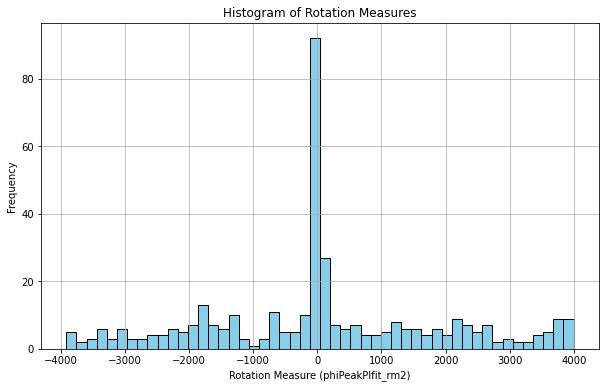

In [10]:

# Load the extracted data from the CSV file
data_file = "../paper2/25/RMsyn/extracted_RMsynth_data.csv"  # Update this path if necessary
df = pd.read_csv(data_file)

# Plot histogram of the Rotation Measures (phiPeakPIfit_rm2)
plt.figure(figsize=(10, 6))
plt.hist(df['RM'], bins=50, color='skyblue', edgecolor='black')  # Adjust bins as needed
plt.xlabel('Rotation Measure (phiPeakPIfit_rm2)')
plt.ylabel('Frequency')
plt.title('Histogram of Rotation Measures')
plt.grid(True)
plt.show()


# Filter True Detection

In [11]:
# Directory containing the .dat files
directory = "../paper2/25/RMsyn/"  # Update this to your actual directory path

# List to store extracted data
data_list = []

# Detection criteria thresholds
snr_threshold = 3  # SNR threshold
fracPol_threshold = 0.005  # Fractional polarization threshold
chi_square_threshold = 10  # Reduced chi-square threshold

# Loop through all files in the directory
for filename in os.listdir(directory):
    if filename.endswith("_RMsynth.dat"):
        # Extract RA and Dec from the filename
        ra_dec_str = filename.split("_combined_RMsynth.dat")[0]
        ra = float(ra_dec_str[2:9].replace('+', ''))
        dec = float(ra_dec_str[9:].replace('+', ''))

        # Path to the current file
        file_path = os.path.join(directory, filename)
        
        # Initialize variables
        phiPeakPIfit_rm2, dPhiPeakPIfit_rm2 = None, None
        snrPIfit, fracPol, IfitChiSqRed = None, None, None

        # Read the file and extract the required values
        with open(file_path, 'r') as file:
            for line in file:
                if 'phiPeakPIfit_rm2' in line:
                    phiPeakPIfit_rm2 = float(line.split('=')[-1].strip())
                elif 'dPhiPeakPIfit_rm2' in line:
                    dPhiPeakPIfit_rm2 = float(line.split('=')[-1].strip())
                elif 'snrPIfit' in line:
                    snrPIfit = float(line.split('=')[-1].strip())
                elif 'fracPol' in line:
                    fracPol = float(line.split('=')[-1].strip())
                elif 'IfitChiSqRed' in line:
                    IfitChiSqRed = float(line.split('=')[-1].strip())

        # Print the values for each source for debugging
        print(f"\nSource: {filename}")
        print(f"  RA: {ra}, Dec: {dec}")
        print(f"  RM: {phiPeakPIfit_rm2}, dRM: {dPhiPeakPIfit_rm2}")
        print(f"  SNR: {snrPIfit}, Fractional Polarization: {fracPol}, Reduced Chi-Square: {IfitChiSqRed}")

        # Apply detection criteria and log each criterion failure
        if (phiPeakPIfit_rm2 is not None and dPhiPeakPIfit_rm2 is not None and
            snrPIfit is not None and fracPol is not None and IfitChiSqRed is not None):

            # Criteria checks
            passed = True
            if snrPIfit < snr_threshold:
                print(f"  SNR below threshold: {snrPIfit} < {snr_threshold}")
                passed = False
            if fracPol < fracPol_threshold:
                print(f"  Fractional Polarization below threshold: {fracPol} < {fracPol_threshold}")
                passed = False
            if IfitChiSqRed > chi_square_threshold:
                print(f"  Reduced Chi-Square too high: {IfitChiSqRed} > {chi_square_threshold}")
                passed = False

            # Add source to the data list if it passes all criteria
            if passed:
                data_list.append({
                    'RA': ra,
                    'Dec': dec,
                    'RM': phiPeakPIfit_rm2,
                    'dRM': dPhiPeakPIfit_rm2,
                    'SNR': snrPIfit,
                    'Fractional Polarization': fracPol,
                    'Reduced Chi-Square': IfitChiSqRed
                })
            else:
                print(f"Source {filename} did not pass detection criteria.")
        else:
            print(f"Warning: Missing data in file {filename}")

# Create a DataFrame from the data list
df = pd.DataFrame(data_list)

# Save to a CSV file
output_csv_path = os.path.join(directory, "filtered_RMsynth_data.csv")
df.to_csv(output_csv_path, index=False)

print(f"\nFiltered data saved to {output_csv_path}")

# Print the contents of the DataFrame for verification
print("\nFiltered DataFrame:")
print(df)



Source: H+51.284+30.309_combined_RMsynth.dat
  RA: 51.284, Dec: 30.309
  RM: 3432.756118657099, dRM: 30.642930618268537
  SNR: 2.0330032116426877, Fractional Polarization: 0.09365582410754326, Reduced Chi-Square: 1.2229905487112478
  SNR below threshold: 2.0330032116426877 < 3
Source H+51.284+30.309_combined_RMsynth.dat did not pass detection criteria.

Source: H+51.465+28.878_combined_RMsynth.dat
  RA: 51.465, Dec: 28.878
  RM: 3995.643294989428, dRM: 37.82294085644393
  SNR: 1.6470738380056547, Fractional Polarization: 0.16386259798724523, Reduced Chi-Square: 2.079173997619011
  SNR below threshold: 1.6470738380056547 < 3
Source H+51.465+28.878_combined_RMsynth.dat did not pass detection criteria.

Source: H+50.852+29.810_combined_RMsynth.dat
  RA: 50.852, Dec: 29.81
  RM: 3995.718394926692, dRM: 38.15079164679476
  SNR: 1.6329196242594324, Fractional Polarization: 0.16022749772105768, Reduced Chi-Square: 1.5446228717623498
  SNR below threshold: 1.6329196242594324 < 3
Source H+50.8


Source: H+50.838+29.407_combined_RMsynth.dat
  RA: 50.838, Dec: 29.407
  RM: -6.364194340354051, dRM: 21.272365643082132
  SNR: 2.92854952788682, Fractional Polarization: 0.14969692908478502, Reduced Chi-Square: 1.6704858824196227
  SNR below threshold: 2.92854952788682 < 3
Source H+50.838+29.407_combined_RMsynth.dat did not pass detection criteria.

Source: H+52.077+28.846_combined_RMsynth.dat
  RA: 52.077, Dec: 28.846
  RM: 3314.901489577499, dRM: 34.468891197054575
  SNR: 1.8073449477947634, Fractional Polarization: 0.05771552547095495, Reduced Chi-Square: 2.083335506797013
  SNR below threshold: 1.8073449477947634 < 3
Source H+52.077+28.846_combined_RMsynth.dat did not pass detection criteria.

Source: H+51.365+30.290_combined_RMsynth.dat
  RA: 51.365, Dec: 30.29
  RM: 3045.0045114833756, dRM: 22.326430471801444
  SNR: 2.790288238855113, Fractional Polarization: 0.11767709200943186, Reduced Chi-Square: 1.0343381917471945
  SNR below threshold: 2.790288238855113 < 3
Source H+51.365


Source: H+50.565+29.245_combined_RMsynth.dat
  RA: 50.565, Dec: 29.245
  RM: 82.94292351086776, dRM: 14.701342270418873
  SNR: 4.237516222340765, Fractional Polarization: 0.011073487932076714, Reduced Chi-Square: 4.830449646196965

Source: H+51.278+29.408_combined_RMsynth.dat
  RA: 51.278, Dec: 29.408
  RM: 1356.5468593144988, dRM: 33.55905603044667
  SNR: 1.8563447167454434, Fractional Polarization: 0.01896306899903954, Reduced Chi-Square: 3.568541183861727
  SNR below threshold: 1.8563447167454434 < 3
Source H+51.278+29.408_combined_RMsynth.dat did not pass detection criteria.

Source: H+50.591+29.570_combined_RMsynth.dat
  RA: 50.591, Dec: 29.57
  RM: 1983.9562373235335, dRM: 25.873752206132234
  SNR: 2.407736452941649, Fractional Polarization: 0.07496916005344291, Reduced Chi-Square: 1.8594547806881843
  SNR below threshold: 2.407736452941649 < 3
Source H+50.591+29.570_combined_RMsynth.dat did not pass detection criteria.

Source: H+51.098+30.123_combined_RMsynth.dat
  RA: 51.098,

In [12]:
df

,RA,Dec,RM,dRM,SNR,Fractional Polarization,Reduced Chi-Square
0,51.874,30.247,36.281827,1.705793,36.520953,0.110627,5.307022
1,51.831,30.320,35.389573,16.412799,3.795646,0.036148,1.912166
2,51.781,29.815,8.600713,7.011413,8.885110,0.102919,4.615267
3,51.321,29.831,35.560416,11.637693,5.353052,0.192529,2.915847
4,52.005,28.815,11.336738,19.064727,3.267667,0.014085,6.969112
...,...,...,...,...,...,...,...
57,51.461,29.146,18.571265,3.270662,19.047271,0.123685,3.337737
58,50.905,30.076,35.570160,4.549014,13.694656,0.040232,2.952028
59,51.480,28.849,1.831821,19.500531,3.194640,0.040884,3.518208
60,51.113,30.423,30.661452,19.673544,3.166546,0.105344,1.304452


In [13]:
pd.set_option('display.max_rows', None)

# Print the entire RM column
print("All RM values:")
print(df['RM'])

All RM values:
0       36.281827
1       35.389573
2        8.600713
3       35.560416
4       11.336738
5      -13.191928
6       16.165318
7       50.141464
8       23.566673
9       16.116170
10      33.507227
11      31.875299
12      28.177069
13      24.819582
14       4.813332
15      91.281561
16      29.924572
17     -18.726609
18      14.366131
19      31.796890
20       4.786241
21      15.125493
22      15.988287
23      50.760986
24      15.360690
25      42.271687
26      34.511355
27      28.297391
28      36.738465
29      28.974467
30      32.403475
31       3.822705
32     811.622371
33      38.778120
34      11.761099
35      15.913321
36       4.568948
37      16.066573
38      14.492885
39      67.158780
40      42.434427
41      18.689354
42      34.901138
43      35.024042
44       8.045042
45      27.125363
46      20.649870
47      23.228064
48      24.002150
49      10.036971
50     970.315823
51       9.101299
52      29.293424
53     137.419920
54      82.94

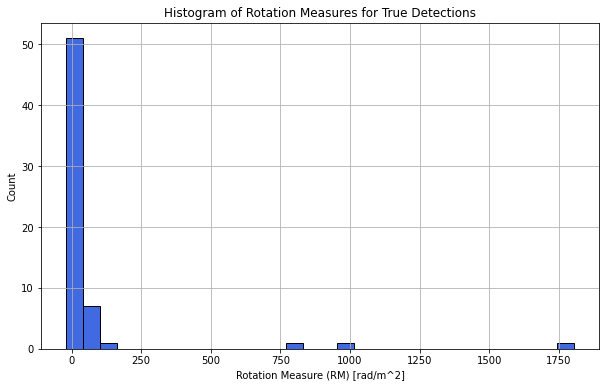

In [14]:
# Load the CSV file containing true detections
true_detections_file = "../paper2/25/RMsyn/filtered_RMsynth_data.csv"  # Update with your file path
df = pd.read_csv(true_detections_file)

# Extract the RM column for plotting
rm_values = df['RM']

# Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(rm_values, bins=30, color='royalblue', edgecolor='black')
plt.xlabel("Rotation Measure (RM) [rad/m^2]")
plt.ylabel("Count")
plt.title("Histogram of Rotation Measures for True Detections")
plt.grid(True)
plt.show()


In [116]:
# Load the true detections CSV
true_detections_file = "../paper2/25/RMsyn/filtered_RMsynth_data.csv"
df = pd.read_csv(true_detections_file)

# Check if any negative RMs exist
negative_rms = df[df['RM'] < 0]
print(f"Number of negative RMs: {len(negative_rms)}")
print(negative_rms[['RA', 'Dec', 'RM', 'dRM']])  # Display any negative RMs if they exist


Number of negative RMs: 2
        RA     Dec         RM        dRM
5   50.503  30.249 -13.191928  27.557450
17  52.113  30.438 -18.726609  53.027312


Set OBSGEO-B to    34.078827 from OBSGEO-[XYZ].
Set OBSGEO-H to     2115.607 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


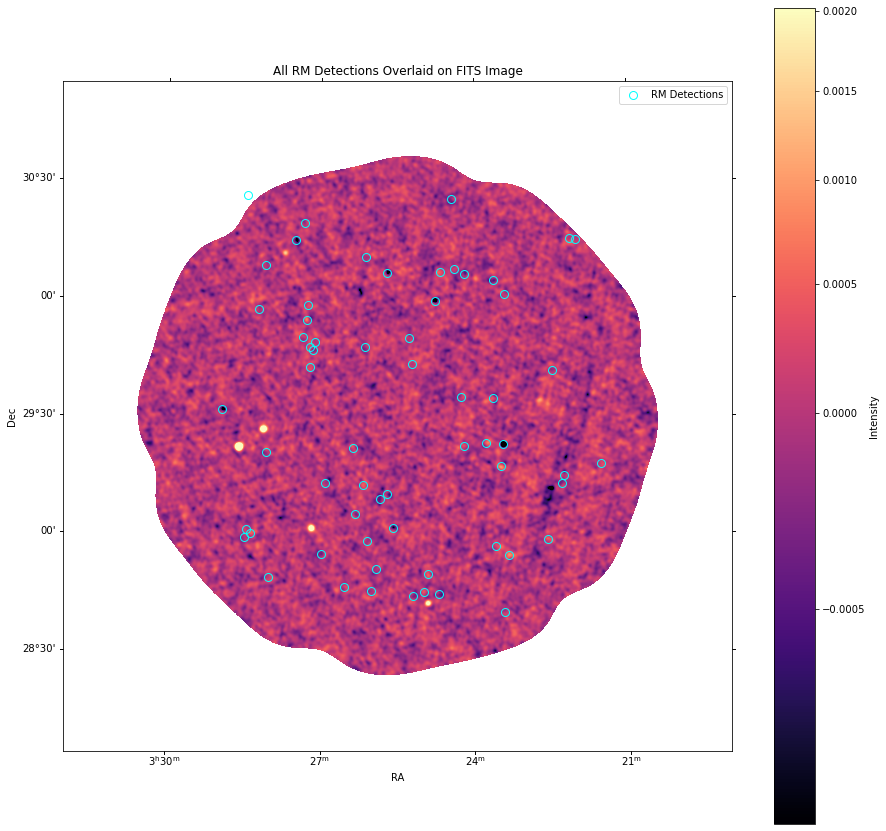

In [117]:
# Load the data from your CSV file containing the RM detections
df = pd.read_csv('../paper2/25/RMsyn/filtered_RMsynth_data.csv')

# Load the FITS file and WCS information
fits_file = '../paper2/25/spw2-16~23-2.5arcsec-nit5000-2e-4-Q.image.smo.fits'
hdulist = fits.open(fits_file)
img_data = hdulist[0].data
wcs = WCS(hdulist[0].header)
hdulist.close()

# Adjust the image data to 2D if necessary
if img_data.ndim > 2:
    img_data = img_data[0, 0, :, :]  # Selecting the first Stokes and frequency slice

# Apply normalization with `simple_norm`
norm = simple_norm(img_data, 'sqrt', percent=99.9)

# Extract RA and Dec for all detections
ra_list = df['RA'].values
dec_list = df['Dec'].values

# Convert RA and DEC to pixel coordinates
frequency = 1.47339395E9  # Placeholder frequency if needed
stokes = 0  # Placeholder Stokes parameter if needed
world_coords = np.column_stack((ra_list, dec_list, [frequency] * len(ra_list), [stokes] * len(dec_list)))
pixel_coords = wcs.all_world2pix(world_coords, 0)

# Plotting
plt.figure(figsize=(15, 15))
ax = plt.subplot(projection=wcs, slices=('x', 'y', 0, 0))  # Specify 4D slices to project correctly
plt.imshow(img_data, origin='lower', cmap='magma', norm=norm)  # Use magma colormap
plt.colorbar(label='Intensity')

# Overlay all RM detection source positions with unfilled circles
ax.plot(pixel_coords[:, 0], pixel_coords[:, 1], 'o', markerfacecolor='none', color='cyan', markersize=8, label='RM Detections')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.legend()
plt.title("All RM Detections Overlaid on FITS Image")
plt.grid(True)

plt.show()
